In [10]:
!pip install setfit datasets pandas
!pip install pipline

1. Setup & Configuration
Import necessary libraries and define models, confidence thresholds, and computation devices.

In [11]:
import pandas as pd
import torch
from transformers import pipeline, AutoModelForSeq2SeqLM, AutoTokenizer
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# Configuration
LID_MODEL = "papluca/xlm-roberta-base-language-detection"
TRANS_MODEL = "facebook/nllb-200-distilled-600M"
ALLOWED_LANGS = ['de', 'fr', 'en']

# Only accept translation with confidence of 0.85
MIN_CONFIDENCE = 0.85

# Use Collab GPU if available, else CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64

print(f"Running on device: {DEVICE}")

Running on device: cuda


In [12]:
!wget -O departments.csv https://raw.githubusercontent.com/konradfuniwue/PracticalDataScience/refs/heads/main/Data/Original%20Data/department-v2.csv
# Load data using the correct filename
df = pd.read_csv('departments.csv')
# Rename columns (adjust based on actual column names in the CSV)
df = df.rename(columns={'job_description': 'text', 'department': 'labels'})

--2026-01-31 19:40:08--  https://raw.githubusercontent.com/konradfuniwue/PracticalDataScience/refs/heads/main/Data/Original%20Data/department-v2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 468519 (458K) [text/plain]
Saving to: ‘departments.csv’

departments.csv     100%[===================>] 457.54K  --.-KB/s    in 0.04s   

2026-01-31 19:40:08 (12.4 MB/s) - ‘departments.csv’ saved [468519/468519]



2. Train/Test Split
Split the raw data into Train (80%) and Test (20%). The Test set is set aside and will not be processed further.

In [14]:
text_col = 'text'

print("--- 1. Train/Test Split (stratified) ---")

# Stratify based on labels to keep classes balanced
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

# IMPORTANT: Reset indices for compatible processing later
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)} (Raw/Unprocessed)")

--- 1. Train/Test Split (stratified) ---
Train size: 8116
Test size:  2029 (Raw/Unprocessed)


3. Language Detection (Train Set Only)
Identify the language and confidence score for the training data.

In [15]:
print("2. Language & Confidence (Train Only) ")

# Initialize Pipeline
pipe = pipeline("text-classification", model=LID_MODEL, device=DEVICE, top_k=1, truncation=True)

# Create Dataset object from Train DF
dataset = Dataset.from_pandas(train_df[[text_col]])

results = []

# Batch-Inference on Train Set
for out in tqdm(pipe(KeyDataset(dataset, text_col), batch_size=BATCH_SIZE), total=len(train_df)):
    results.append(out[0])

# Append results to Train DataFrame
train_df['lang'] = [r['label'] for r in results]
train_df['score'] = [r['score'] for r in results]

# Clean memory
del pipe
torch.cuda.empty_cache()

train_df.head()

2. Language & Confidence (Train Only) 


Device set to use cuda


  0%|          | 0/8116 [00:00<?, ?it/s]

,text,label,lang,score
0,Team Assistance Marketing Communications,Marketing,en,0.966908
1,Trainee Performance Marketing,Marketing,en,0.824862
2,Assistentin der Geschäftsleitung,Administrative,de,0.993325
3,Leiterin Marketing und Vertrieb,Marketing,de,0.994776
4,Technical Sales Representative,Sales,en,0.826825


4. Data Cleaning (Train Set Only)
Remove rows from the training set that are not in the allowed languages or have low confidence.

In [16]:
print(" 3. Data Cleaning (Train Only) ")

initial_len = len(train_df)

# Filter Condition
mask = (train_df['lang'].isin(ALLOWED_LANGS)) & (train_df['score'] >= MIN_CONFIDENCE)
train_final = train_df[mask].copy()

dropped_count = initial_len - len(train_final)

print(f"Train set cleaned: Originally {initial_len}, Filtered {len(train_final)} (Dropped: {dropped_count} rows)")
print("Distribution in train set after filter (Language):\n", train_final['lang'].value_counts())

 3. Data Cleaning (Train Only) 
Train set cleaned: Originally 8116, Filtered 6194 (Dropped: 1922 rows)
Distribution in train set after filter (Language):
 lang
en    3166
de    2912
fr     116
Name: count, dtype: int64


5. Translation (Train Set Only)
Translate German and French entries in the training set to English.

In [20]:
tokenizer = AutoTokenizer.from_pretrained(TRANS_MODEL)
model = AutoModelForSeq2SeqLM.from_pretrained(TRANS_MODEL).to(DEVICE)
forced_bos_id = tokenizer.convert_tokens_to_ids("eng_Latn")
lang_map = {'de': 'deu_Latn', 'fr': 'fra_Latn'}

def translate_subset(sub_df):
    sub_df['text_en'] = sub_df[text_col].astype(str) # Default: keep original

    for lang, nllb_code in lang_map.items():
        indices = sub_df[sub_df['lang'] == lang].index
        if len(indices) == 0: continue

        texts = sub_df.loc[indices, text_col].tolist()
        translated = []

        for i in tqdm(range(0, len(texts), BATCH_SIZE), desc=f"Trans {lang}", leave=False):
            batch = texts[i:i+BATCH_SIZE]
            tokenizer.src_lang = nllb_code
            inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(model.device)

            with torch.no_grad():
                out = model.generate(**inputs, forced_bos_token_id=forced_bos_id, max_length=128)

            translated.extend(tokenizer.batch_decode(out, skip_special_tokens=True))

        sub_df.loc[indices, 'text_en'] = translated
    return sub_df

print("Translating Train Set...")
train_final = translate_subset(train_final)

print("\n--- Summary: Train Set Differences ---")
print(f"Original Train Split: {len(train_df)} rows")
print(f"Final Cleaned Train:  {len(train_final)} rows")
print(f"Difference (Dropped): {len(train_df) - len(train_final)} rows")

Translating Train Set...


Trans de:   0%|          | 0/46 [00:00<?, ?it/s]

Trans fr:   0%|          | 0/2 [00:00<?, ?it/s]


--- Summary: Train Set Differences ---
Original Train Split: 8116 rows
Final Cleaned Train:  6194 rows
Difference (Dropped): 1922 rows


6. Visualization: Cleaning Impact
Compare the class distribution of the original training split train_df versus the final cleaned version train_final to see how much data was lost per class.

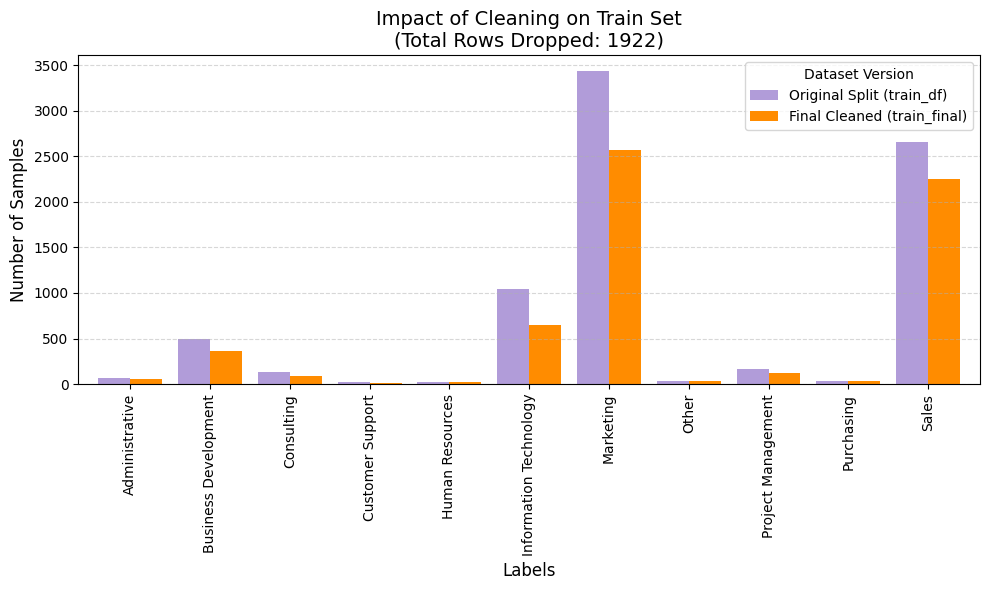

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Original Split (train_df)': train_df['label'].value_counts(),
    'Final Cleaned (train_final)': train_final['label'].value_counts()
}).sort_index()

# Calculate total dropped rows
total_dropped = len(train_df) - len(train_final)


ax = comparison_df.plot(kind='bar', figsize=(10, 6), color=['#b19cd9', '#ff8c00'], width=0.8)

# Customizing the plot
ax.set_title(f'Impact of Cleaning on Train Set\n(Total Rows Dropped: {total_dropped})', fontsize=14)
ax.set_xlabel('Labels', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.legend(title="Dataset Version")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()